In [11]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from data.data_processor_fix import DataProcessor as DP
from data.splitter import SurvivalSplitter
from data.RFMFeatures import RFMFeatures
from models.cox_model_upd import CoxModelUpd
from models.rsf_model import RSFModel
from metrics.ibs import IBSMetric
from metrics.auprc import AUPRCMetric
from metrics.evaluator import SurvivalEvaluator
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [12]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
df.info()
#print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18668 entries, 0 to 18667
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     18668 non-null  object 
 1   age                      18668 non-null  int64  
 2   sex                      18668 non-null  object 
 3   race                     18668 non-null  object 
 4   c_charge_degree          17883 non-null  object 
 5   c_charge_desc            17870 non-null  object 
 6   in_custody               18074 non-null  object 
 7   out_custody              18074 non-null  object 
 8   custody_num              18668 non-null  int64  
 9   time_to_last_custody     7797 non-null   float64
 10  time_since_last_arrest   7797 non-null   float64
 11  time_to_future_arrest    7797 non-null   float64
 12  event                    18668 non-null  int64  
 13  event_of_future_arrest   18668 non-null  int64  
 14  curr_dur_custody      

In [13]:
processor = DP("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df['c_charge_degree'] = cox_df['c_charge_degree'].str.strip('()')
cox_df['race'] = cox_df['race'].str.strip('').str.upper()
cox_df['sex'] = cox_df['sex'].str.strip().str.upper()
sex_mapping = {
    'MALE': 0,
    'FEMALE': 1
}
cox_df['sex'] = cox_df['sex'].map(sex_mapping)
cox_df.head()
cox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7772 entries, 0 to 7771
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    7772 non-null   object 
 1   episode_col             7772 non-null   int64  
 2   start                   7772 non-null   float64
 3   stop                    7772 non-null   float64
 4   event                   7772 non-null   int64  
 5   age                     7772 non-null   int64  
 6   sex                     7772 non-null   int64  
 7   race                    7772 non-null   object 
 8   c_charge_degree         7667 non-null   object 
 9   time_since_last_arrest  7772 non-null   float64
 10  curr_dur_custody        7772 non-null   float64
dtypes: float64(4), int64(4), object(3)
memory usage: 668.0+ KB


In [14]:
features_for_rfm = ["curr_dur_custody", "time_since_last_arrest"]
operations = ["min", "max", "mean"]

rfm = RFMFeatures(id_col="name", episode_col="episode_col")
cox_df = rfm.create(
    df=cox_df,
    history_features=features_for_rfm,
    operations=operations
)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
cox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7772 entries, 0 to 7771
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            7772 non-null   object 
 1   episode_col                     7772 non-null   int64  
 2   start                           7772 non-null   float64
 3   stop                            7772 non-null   float64
 4   event                           7772 non-null   int64  
 5   age                             7772 non-null   int64  
 6   sex                             7772 non-null   int64  
 7   race                            7772 non-null   object 
 8   c_charge_degree                 7667 non-null   object 
 9   time_since_last_arrest          7772 non-null   float64
 10  curr_dur_custody                7772 non-null   float64
 11  curr_dur_custody_history        7772 non-null   object 
 12  time_since_last_arrest_history  77

Data split into train and test data

In [16]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])
train_df["time"] = train_df["stop"] - train_df["start"]
test_df["time"] = test_df["stop"] - test_df["start"]

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [17]:
ohe = OneHotEncoder(
    drop='first',
    sparse_output=True,
    handle_unknown='ignore'
)

categorical_cols = ['c_charge_degree', 'race']
ohe.fit(train_df[categorical_cols])

train_encoded = ohe.transform(train_df[categorical_cols])
test_encoded = ohe.transform(test_df[categorical_cols])
train_encoded_dense = train_encoded.toarray()
test_encoded_dense = test_encoded.toarray()

encoded_cols = ohe.get_feature_names_out(categorical_cols)
train_encoded_df = pd.DataFrame(train_encoded_dense, columns=encoded_cols, index=train_df.index)
test_encoded_df = pd.DataFrame(test_encoded_dense, columns=encoded_cols, index=test_df.index)

train_df = train_df.drop(columns=categorical_cols)
test_df = test_df.drop(columns=categorical_cols)

train_df = pd.concat([train_df, train_encoded_df], axis=1)
test_df = pd.concat([test_df, test_encoded_df], axis=1)

In [18]:
train_df.query("name=='daniel diaz'")

,name,episode_col,start,stop,event,age,sex,time_since_last_arrest,curr_dur_custody_history,time_since_last_arrest_history,...,c_charge_degree_M1,c_charge_degree_M2,c_charge_degree_MO3,c_charge_degree_NI0,c_charge_degree_nan,race_ASIAN,race_CAUCASIAN,race_HISPANIC,race_NATIVE AMERICAN,race_OTHER
1171,daniel diaz,1,0.0,104.0,1,50,0,70.0,[],[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1172,daniel diaz,2,104.0,159.0,1,50,0,24.0,[31.0],[70.0],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1173,daniel diaz,3,159.0,235.0,1,50,0,12.0,"[31.0, 64.0]","[70.0, 24.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1174,daniel diaz,4,235.0,261.0,1,50,0,25.0,"[31.0, 64.0, 1.0]","[70.0, 24.0, 12.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1175,daniel diaz,5,261.0,391.0,1,50,0,12.0,"[31.0, 64.0, 1.0, 118.0]","[70.0, 24.0, 12.0, 25.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1176,daniel diaz,6,391.0,1079.0,1,50,0,509.0,"[31.0, 64.0, 1.0, 118.0, 179.0]","[70.0, 24.0, 12.0, 25.0, 12.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1177,daniel diaz,7,1079.0,1088.0,1,50,0,7.0,"[31.0, 64.0, 1.0, 118.0, 179.0, 2.0]","[70.0, 24.0, 12.0, 25.0, 12.0, 509.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1178,daniel diaz,8,1088.0,1128.0,0,50,0,6.0,"[31.0, 64.0, 1.0, 118.0, 179.0, 2.0, 34.0]","[70.0, 24.0, 12.0, 25.0, 12.0, 509.0, 7.0]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [19]:
# Get ONLY Daniel Diaz + ONLY the 4 columns for your graph
daniel_df = train_df[
    train_df["name"] == "daniel diaz"  # filter by name
][["name", "episode_col", "start", "stop", "event"]]  # columns for graph

# Show it (to confirm)
print(daniel_df)

             name  episode_col   start    stop  event
1171  daniel diaz            1     0.0   104.0      1
1172  daniel diaz            2   104.0   159.0      1
1173  daniel diaz            3   159.0   235.0      1
1174  daniel diaz            4   235.0   261.0      1
1175  daniel diaz            5   261.0   391.0      1
1176  daniel diaz            6   391.0  1079.0      1
1177  daniel diaz            7  1079.0  1088.0      1
1178  daniel diaz            8  1088.0  1128.0      0


In [24]:
features = [c for c in train_df.columns 
            if c not in ["name", "start", "time", "event", "stop"]
            and not c.endswith("_history")]

cols_for_model = ["name", "start", "stop", "event", "time"] + features
train_model_df = train_df[cols_for_model].copy().fillna(-1)
test_df = test_df.fillna(-1)

In [25]:
display(train_model_df.groupby("episode_col").size())
display(test_df.groupby("episode_col").size())

episode_col
1     3382
2     1503
3      680
4      304
5      148
6       77
7       37
8       11
9        5
10       2
dtype: int64

episode_col
1     845
2     435
3     184
4      78
5      34
6      16
7      13
8       5
9       4
10      4
11      3
12      2
dtype: int64

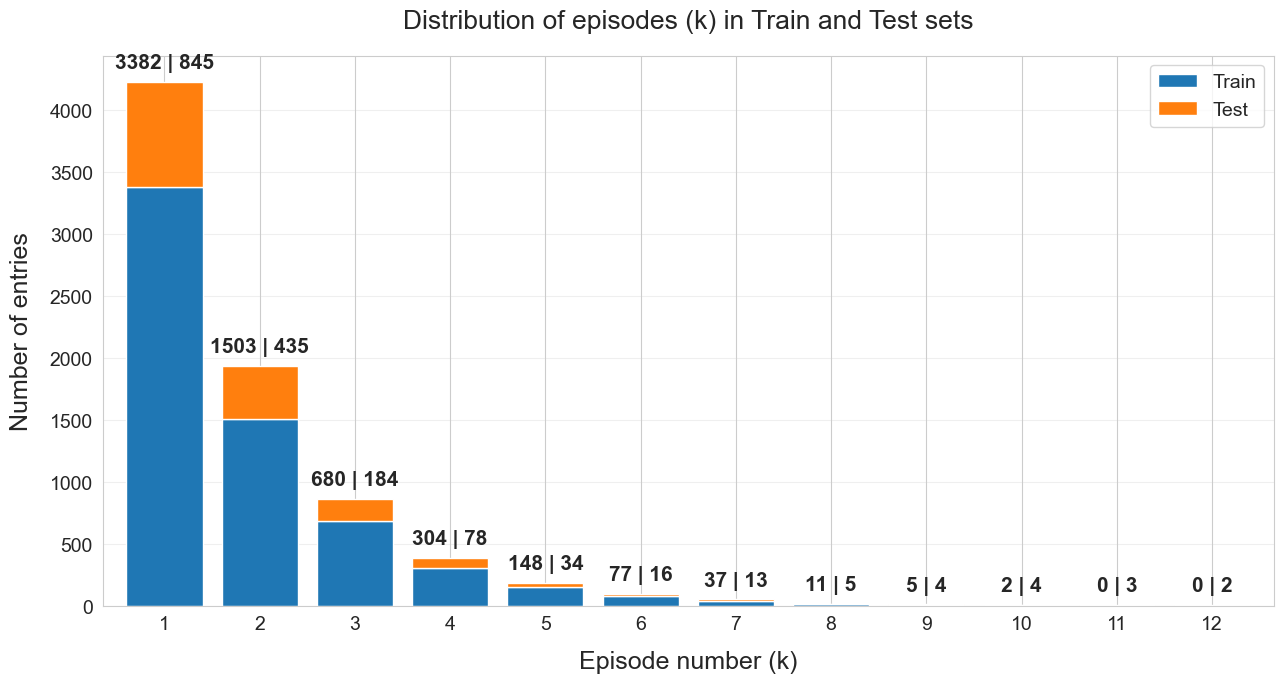

In [ ]:
train_counts = train_model_df.groupby("episode_col").size()
test_counts = test_df.groupby("episode_col").size()

plot_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
}).fillna(0).astype(int)

plt.figure(figsize=(13, 7))
ax = plot_df.plot(kind='bar', stacked=True, ax=plt.gca(),
                  color=['#1f77b4', '#ff7f0e'], width=0.8)

plt.title('Distribution of episodes (k) in Train and Test sets', fontsize=19, pad=20)
plt.xlabel('Episode number (k)', fontsize=18, labelpad=12)
plt.ylabel('Number of entries', fontsize=18, labelpad=12)
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Train | Test
for i, (idx, row) in enumerate(plot_df.iterrows()):
    train_val = int(row['Train'])
    test_val = int(row['Test'])
    # Текст: 3382 | 845
    label = f'{train_val} | {test_val}'
    ax.text(i, train_val + test_val + 80, label,
            ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
test_model_df = test_df.query(f"episode_col.isin({train_model_df['episode_col'].unique().tolist()})")

In [12]:
horizon = np.quantile(train_model_df["stop"] - train_model_df["start"], 0.95)
times = np.linspace(0, horizon, 200)

In [13]:
# models = {}

# for model_mode in ["recurrent", "independent"]:
#     for use_episode in [True, False]:
#         for penalizer in [0.0, 0.01, 0.1]:
#             name = f"CoxUpd_{model_mode[:3]}_{'with' if use_episode else 'no'}_k_pen_{penalizer}"
#             print(name)
#             features_model = features.copy()
#             if not(use_episode):
#                 features_model.remove("episode_col")

#             model = CoxModelUpd(
#                 features=features_model,
#                 mode=model_mode,
#                 use_episode=use_episode,
#                 penalizer=penalizer    
#             )
#             if model_mode == "recurrent":
#                 model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
#             else:
#                 model.fit(train_model_df[features_model + ["time", "event"]])
#             model.features = features_model
#             models[name] = model

# features_rsf = features.copy()
# features_rsf.remove("episode_col")
# train_rsf_df = train_df[["time","event"] + features_rsf].copy()
# rsf_model = RSFModel(features=features_rsf)
# rsf_model.fit(train_rsf_df)
# rsf_model.features = features_rsf
# models["RSF_no_episode_col"] = rsf_model

In [14]:
train_model_df.info()
test_model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6149 entries, 0 to 6148
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         6149 non-null   object 
 1   start                        6149 non-null   float64
 2   stop                         6149 non-null   float64
 3   event                        6149 non-null   int64  
 4   time                         6149 non-null   float64
 5   episode_col                  6149 non-null   int64  
 6   age                          6149 non-null   int64  
 7   sex                          6149 non-null   int64  
 8   time_since_last_arrest       6149 non-null   float64
 9   curr_dur_custody_min         6149 non-null   float64
 10  curr_dur_custody_max         6149 non-null   float64
 11  curr_dur_custody_mean        6149 non-null   float64
 12  time_since_last_arrest_min   6149 non-null   float64
 13  time_since_last_ar

In [15]:
from sklearn.model_selection import ParameterGrid

models_grid = {
    "CoxUpd_rec": {'model': CoxModelUpd, 'mode': 'recurrent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.1]}},
    "CoxUpd_ind": {'model': CoxModelUpd, 'mode': 'independent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.0, 0.1]}},
    "RSF_ind": {'model': RSFModel, 'mode': 'independent',
                'hyperparams_grid': {'use_episode': [True, False], 'n_estimators': [100, 200], 'min_samples_split': [2]}}
}

models = {}

for mdl in models_grid.keys():
    model_proto = models_grid[mdl]
    for params in ParameterGrid(model_proto['hyperparams_grid']):
        name = f"{mdl}_{'_'.join([f'{k}_{v}' for k, v in params.items()])}"
        print(name)
        features_model = features.copy()
        if not(params['use_episode']):
            features_model.remove("episode_col")

        model = model_proto['model'](
            features=features_model,
            mode=model_proto['mode'],
            **params
        )
        if model_proto['mode'] == "recurrent":
            model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
        else:
            model.fit(train_model_df[features_model + ["time", "event"]])
        models[name] = model

CoxUpd_rec_penalizer_0.1_use_episode_True


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
penalizer,0.1
l1 ratio,0.0
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_penalizer_0.1_use_episode_False


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
penalizer,0.1
l1 ratio,0.0
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.0_use_episode_True


...

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_True


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -20758.32
         time fit was run = 2026-03-25 08:01:55 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
episode_col                  0.18      1.20      0.02            0.15            0.22                1.16                1.24
age                         -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
sex                         -0.03      0.97      0.05           -0.13            0.06                0.88                1.07
time_since_last_arrest      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
curr_dur_custody_min        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
curr_dur_custody_max        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
curr_dur_custody_mean       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
time_since_last_arrest_min  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
time_since_last_arrest_max  -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
time_since_last_arrest_mean -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
log_curr_dur_custody        -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
dur_deviation_from_avg      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
custody_increasing           0.46      1.58      0.05            0.36            0.55                1.44                1.74
arrest_speed_trend          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
c_charge_degree_F1          -0.23      0.80      0.16           -0.53            0.08                0.59                1.08
c_charge_degree_F2          -0.07      0.93      0.08           -0.22            0.08                0.80                1.08
c_charge_degree_F3           0.05      1.05      0.06           -0.07            0.16                0.93                1.18
c_charge_degree_F5          -1.32      0.27      1.20           -3.67            1.03                0.03                2.81
c_charge_degree_F6           0.27      1.31      0.65           -1.01            1.55                0.36                4.71
c_charge_degree_F7          -0.15      0.86      0.18           -0.50            0.20                0.61                1.22
c_charge_degree_M1          -0.08      0.93      0.07           -0.21            0.06                0.81                1.06
c_charge_degree_M2          -0.05      0.96      0.08           -0.21            0.12                0.81                1.13
c_charge_degree_MO3          0.36      1.43      0.19           -0.01            0.73                0.99                2.08
c_charge_degree_NI0          0.21      1.23      0.65           -1.06            1.48                0.35                4.38
c_charge_degree_nan          0.40      1.49      0.15            0.10            0.70                1.10                2.02
race_ASIAN                  -0.98      0.38      0.62           -2.20            0.24                0.11                1.27
race_CAUCASIAN              -0.06      0.94  

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_False


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -20812.43
         time fit was run = 2026-03-25 08:01:55 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
age                         -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
sex                         -0.02      0.98      0.05           -0.12            0.07                0.89                1.08
time_since_last_arrest      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
curr_dur_custody_min        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
curr_dur_custody_max        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
curr_dur_custody_mean       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
time_since_last_arrest_min  -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
time_since_last_arrest_max   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
time_since_last_arrest_mean -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
log_curr_dur_custody        -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
dur_deviation_from_avg      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
custody_increasing           0.58      1.79      0.05            0.49            0.67                1.63                1.96
arrest_speed_trend          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
c_charge_degree_F1          -0.24      0.79      0.15           -0.54            0.07                0.58                1.07
c_charge_degree_F2          -0.09      0.91      0.08           -0.24            0.05                0.78                1.06
c_charge_degree_F3           0.05      1.05      0.06           -0.06            0.17                0.94                1.18
c_charge_degree_F5          -1.35      0.26      1.19           -3.68            0.99                0.03                2.69
c_charge_degree_F6           0.22      1.24      0.65           -1.06            1.49                0.35                4.43
c_charge_degree_F7          -0.17      0.84      0.18           -0.52            0.18                0.59                1.20
c_charge_degree_M1          -0.08      0.92      0.07           -0.22            0.05                0.81                1.05
c_charge_degree_M2          -0.04      0.96      0.08           -0.20            0.12                0.82                1.13
c_charge_degree_MO3          0.39      1.47      0.19            0.02            0.76                1.02                2.14
c_charge_degree_NI0          0.15      1.16      0.64           -1.11            1.41                0.33                4.10
c_charge_degree_nan          0.45      1.57      0.15            0.15            0.76                1.16                2.13
race_ASIAN                  -1.02      0.36      0.62           -2.23            0.20                0.11                1.22
race_CAUCASIAN              -0.07      0.94      0.04           -0.14            0.01                0.87                1.01
race_HISPANIC               -0.20      0.82  

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_False
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_False


In [16]:
evaluator = SurvivalEvaluator(
    ibs_metric=IBSMetric(),
    auprc_metric=AUPRCMetric()
)

for name, model in models.items():
    evaluator.evaluate(
        model=model,
        model_name=name,
        train_df=train_model_df,
        test_df=test_model_df,
        features=model.features,
        times=times
    )

evaluator.get_results_table().round(4)

,model,IBS,AUPRC,C-index,recurrent_error,IAUC_RE1,IAUC_RE2,IAUC_RE3
0,CoxUpd_rec_penalizer_0.1_use_episode_True,0.2540,0.5933,0.4928,10.4397,0.7902,0.6598,0.4835
1,CoxUpd_rec_penalizer_0.1_use_episode_False,0.1644,0.6207,0.8591,9.7868,0.8999,0.8575,0.7797
2,CoxUpd_ind_penalizer_0.0_use_episode_True,0.0820,0.6603,0.8371,6.2883,0.8983,0.8484,0.7711
3,CoxUpd_ind_penalizer_0.0_use_episode_False,0.0871,0.6509,0.8227,7.6118,0.8951,0.8441,0.7680
4,CoxUpd_ind_penalizer_0.1_use_episode_True,0.0845,0.6451,0.8503,4.7742,0.9069,0.8808,0.7795
5,CoxUpd_ind_penalizer_0.1_use_episode_False,0.0878,0.6397,0.8472,6.2227,0.9053,0.8748,0.7778
6,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.0672,0.7168,0.8985,0.5274,0.9036,0.9274,0.7937
7,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.0696,0.7133,0.8970,0.5481,0.9039,0.9275,0.7959
8,RSF_ind_min_samples_split_2_n_estimators_200_u...,0.0695,0.7137,0.8993,0.5056,0.9035,0.9308,0.7926
9,RSF_ind_min_samples_split_2_n_estimators_200_u...,0.0686,0.7152,0.8994,0.5088,0.9048,0.9280,0.7951


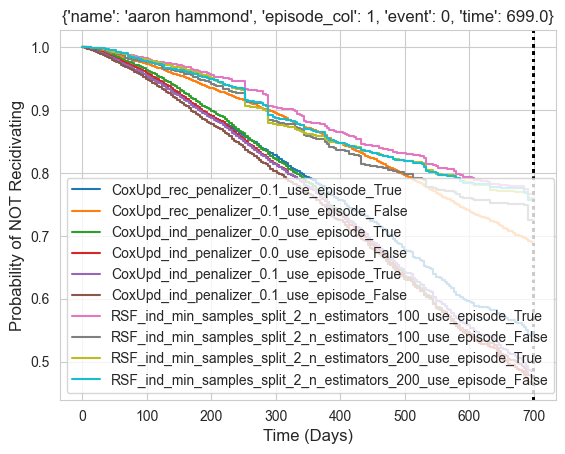

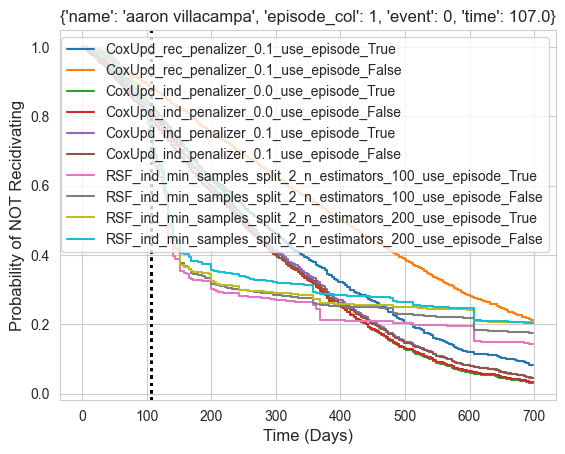

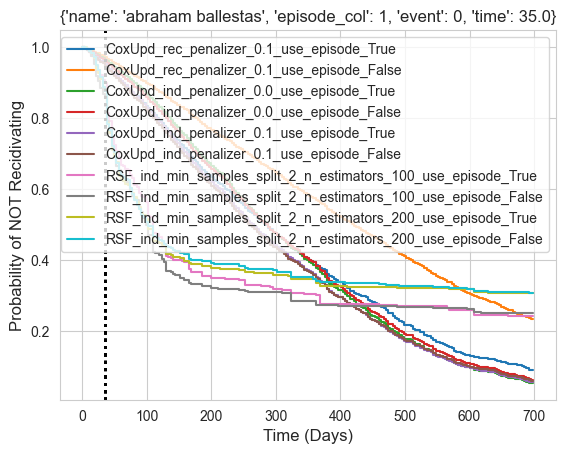

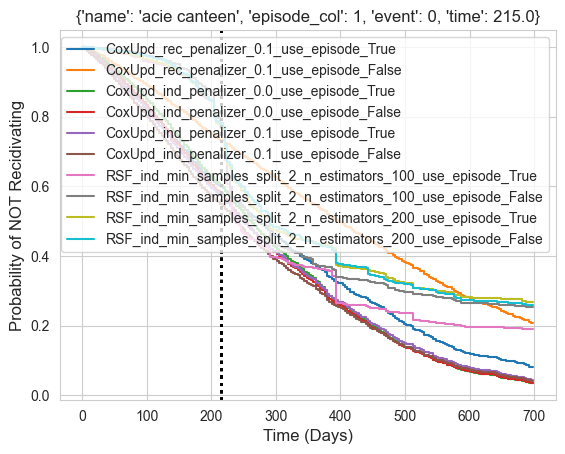

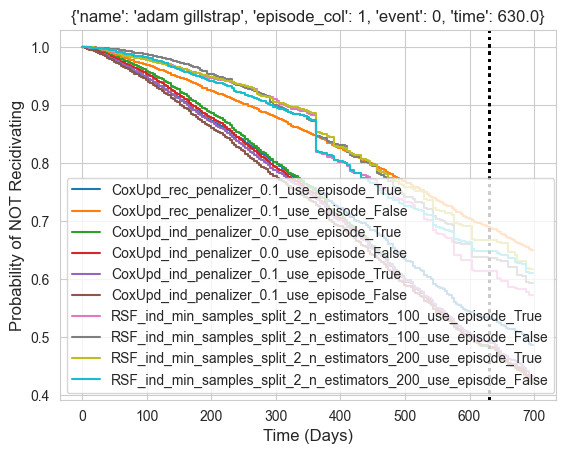

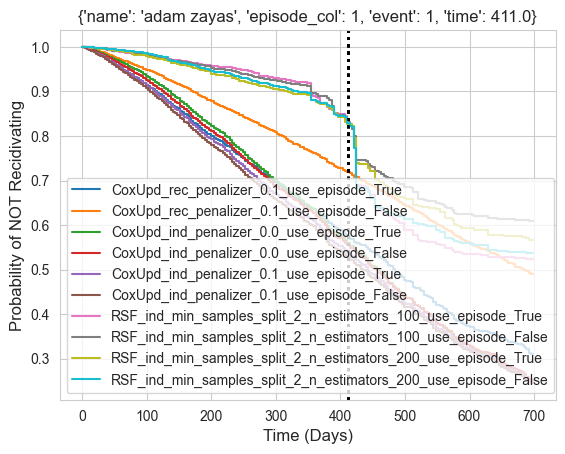

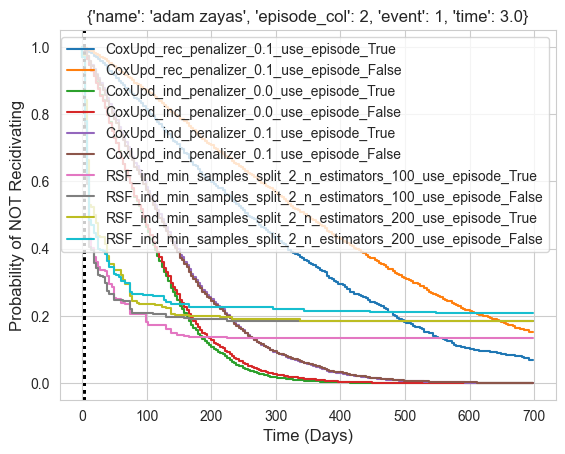

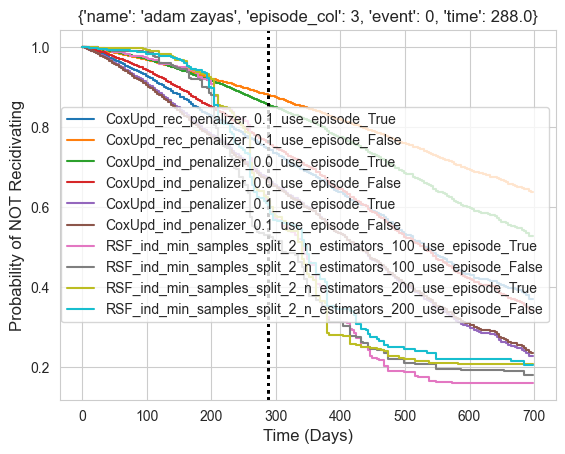

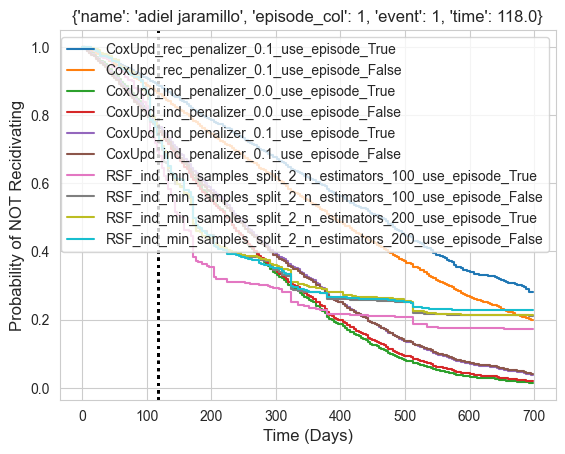

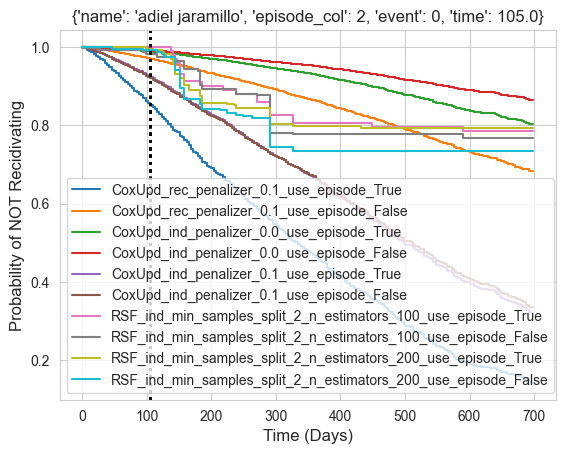

In [17]:
sns.set_style("whitegrid")

for index_test in range(10):
    for name, model in models.items():
        pred = model.predict_survival(test_model_df[features], times)
        plt.step(times, pred.iloc[index_test].values, label=name)
        sample_info = test_model_df.iloc[index_test]
        event_status = "Recidivated" if sample_info["event"] == 1 else "No Recidivism"
        time_to_event = sample_info["time"]
        plt.axvline(
            x=time_to_event,
            color="black",
            linestyle=":",
            linewidth=2,
        )
    # pred = rsf_model.predict_survival(test_model_df[rsf_model.features], times)
    # plt.step(times, pred.iloc[index_test].values, label="RSF_no_episode_col", color="red", linewidth=2)
    # sample_info = test_model_df.iloc[index_test]
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Probability of NOT Recidivating", fontsize=12)
    plt.legend()
    plt.title(f"{test_model_df.iloc[index_test][['name', 'episode_col', 'event', 'time']].to_dict()}")
    plt.show()

In [18]:
train_model_df = train_model_df.drop(columns=[col for col in cox_df.columns if any(
    s in col for s in ["_min", "_max", "_mean", "log_", "_deviation", "_increasing", "_trend"])
])
test_model_df = test_model_df.drop(columns=[col for col in cox_df.columns if any(
    s in col for s in ["_min", "_max", "_mean", "log_", "_deviation", "_increasing", "_trend"])
])
features = [f for f in features if not any(
    s in f for s in ["_min", "_max", "_mean", "log_", "_deviation", "_increasing", "_trend"]
)]

In [ ]:
# train_model_df = train_model_df.drop(columns=["time_since_last_arrest"])
# test_model_df = test_model_df.drop(columns=["time_since_last_arrest"])

In [ ]:
# features = [f for f in features if f != "time_since_last_arrest"]
# features_model = [f for f in features_model if f != "time_since_last_arrest"]

In [24]:
train_model_df.info()
test_model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6149 entries, 0 to 6148
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  6149 non-null   object 
 1   start                 6149 non-null   float64
 2   stop                  6149 non-null   float64
 3   event                 6149 non-null   int64  
 4   time                  6149 non-null   float64
 5   episode_col           6149 non-null   int64  
 6   age                   6149 non-null   int64  
 7   sex                   6149 non-null   int64  
 8   c_charge_degree_F1    6149 non-null   float64
 9   c_charge_degree_F2    6149 non-null   float64
 10  c_charge_degree_F3    6149 non-null   float64
 11  c_charge_degree_F5    6149 non-null   float64
 12  c_charge_degree_F6    6149 non-null   float64
 13  c_charge_degree_F7    6149 non-null   float64
 14  c_charge_degree_M1    6149 non-null   float64
 15  c_charge_degree_M2   

In [28]:
from sklearn.model_selection import ParameterGrid

models_grid = {
    "CoxUpd_rec": {'model': CoxModelUpd, 'mode': 'recurrent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.1]}},
    "CoxUpd_ind": {'model': CoxModelUpd, 'mode': 'independent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.0, 0.1]}},
    "RSF_ind": {'model': RSFModel, 'mode': 'independent',
                'hyperparams_grid': {'use_episode': [True, False], 'n_estimators': [100, 200], 'min_samples_split': [2]}}
}

models = {}

for mdl in models_grid.keys():
    model_proto = models_grid[mdl]
    for params in ParameterGrid(model_proto['hyperparams_grid']):
        name = f"{mdl}_{'_'.join([f'{k}_{v}' for k, v in params.items()])}"
        print(name)
        features_model = features.copy()
        if not(params['use_episode']):
            features_model.remove("episode_col")

        model = model_proto['model'](
            features=features_model,
            mode=model_proto['mode'],
            **params
        )
        if model_proto['mode'] == "recurrent":
            model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
        else:
            model.fit(train_model_df[features_model + ["time", "event"]])
        models[name] = model

CoxUpd_rec_penalizer_0.1_use_episode_True


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
penalizer,0.1
l1 ratio,0.0
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_penalizer_0.1_use_episode_False


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
penalizer,0.1
l1 ratio,0.0
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.0_use_episode_True


...

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_True


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -21916.73
         time fit was run = 2026-03-31 09:14:03 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
episode_col           0.16      1.17      0.01            0.13            0.19                1.14                1.20
age                  -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
sex                  -0.02      0.98      0.05           -0.12            0.08                0.89                1.08
c_charge_degree_F1   -0.26      0.77      0.15           -0.56            0.04                0.57                1.04
c_charge_degree_F2   -0.07      0.93      0.08           -0.22            0.08                0.80                1.08
c_charge_degree_F3    0.09      1.09      0.06           -0.03            0.20                0.97                1.22
c_charge_degree_F5   -1.28      0.28      1.21           -3.65            1.09                0.03                2.96
c_charge_degree_F6   -0.18      0.83      0.62           -1.40            1.04                0.25                2.83
c_charge_degree_F7   -0.16      0.85      0.18           -0.51            0.19                0.60                1.21
c_charge_degree_M1   -0.12      0.89      0.07           -0.25            0.01                0.78                1.02
c_charge_degree_M2   -0.11      0.89      0.08           -0.27            0.05                0.76                1.05
c_charge_degree_MO3   0.37      1.44      0.19           -0.00            0.74                1.00                2.09
c_charge_degree_NI0  -0.11      0.90      0.63           -1.34            1.12                0.26                3.07
c_charge_degree_nan   0.47      1.59      0.15            0.16            0.77                1.18                2.16
race_ASIAN           -0.90      0.41      0.63           -2.14            0.34                0.12                1.40
race_CAUCASIAN       -0.09      0.92      0.04           -0.16           -0.01                0.85                0.99
race_HISPANIC        -0.23      0.79      0.08           -0.39           -0.08                0.68                0.93
race_NATIVE AMERICAN  0.07      1.08      0.41           -0.73            0.88                0.48                2.40
race_OTHER           -0.11      0.90      0.10           -0.30            0.08                0.74                1.09

                      cmp to     z      p  -log2(p)
covariate                                          
episode_col             0.00 11.11 <0.005     92.81
age                     0.00 -5.19 <0.005     22.18
sex                     0.00 -0.43   0.67      0.58
c_charge_degree_F1      0.00 -1.69   0.09      3.45
c_charge_degree_F2      0.00 -0.92   0.36      1.48
c_charge_degree_F3      0.00  1.45   0.15      2.77
c_charge_degree_F5      0.00 -1.06   0.29      1.79
c_charge_degree_F6      0.00 -0.29   0.77      0.37
c_charge_degree_F7      0.00 -0.89   0.37      1.43
c_charge_degree_M1      0.00 -1.74   0.08      3.61
c_charge_degree_M2      0.00 -1.34   0.18      2.46
c_charge_degree_MO3     0.00  1.95   0.05      4.28
c_charge_degree_NI0     0.00 -0.18   0.86      0.22
c_charge_degree_nan     0.00  3.01 <0.005      8.60
race_ASIAN              0.00 -1.43   0.15      2.70
race_CAUCASIAN          0.00 -2.21   0.03      5.21
race_HISPANIC           0.00 -2.93 <0.005      8.21
race_NATIVE AMERICAN    0.00  0.18   0.86      0.22
race_OTHER              0.00 -1.1

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_False


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -21972.62
         time fit was run = 2026-03-31 09:14:03 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
age                  -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
sex                  -0.03      0.97      0.05           -0.12            0.07                0.88                1.07
c_charge_degree_F1   -0.28      0.76      0.15           -0.58            0.02                0.56                1.02
c_charge_degree_F2   -0.08      0.92      0.08           -0.23            0.06                0.79                1.07
c_charge_degree_F3    0.10      1.10      0.06           -0.02            0.21                0.98                1.24
c_charge_degree_F5   -1.35      0.26      1.19           -3.69            0.99                0.03                2.68
c_charge_degree_F6   -0.19      0.83      0.62           -1.41            1.04                0.24                2.82
c_charge_degree_F7   -0.19      0.83      0.18           -0.54            0.16                0.58                1.17
c_charge_degree_M1   -0.13      0.88      0.07           -0.26            0.00                0.77                1.00
c_charge_degree_M2   -0.11      0.89      0.08           -0.28            0.05                0.76                1.05
c_charge_degree_MO3   0.38      1.47      0.19            0.01            0.75                1.01                2.12
c_charge_degree_NI0  -0.10      0.91      0.63           -1.33            1.13                0.26                3.11
c_charge_degree_nan   0.51      1.67      0.16            0.21            0.81                1.23                2.26
race_ASIAN           -0.97      0.38      0.62           -2.19            0.25                0.11                1.29
race_CAUCASIAN       -0.10      0.91      0.04           -0.17           -0.02                0.84                0.98
race_HISPANIC        -0.26      0.77      0.08           -0.42           -0.11                0.66                0.90
race_NATIVE AMERICAN  0.04      1.04      0.41           -0.76            0.84                0.47                2.32
race_OTHER           -0.12      0.89      0.10           -0.31            0.08                0.73                1.08

                      cmp to     z      p  -log2(p)
covariate                                          
age                     0.00 -5.68 <0.005     26.13
sex                     0.00 -0.54   0.59      0.76
c_charge_degree_F1      0.00 -1.80   0.07      3.81
c_charge_degree_F2      0.00 -1.11   0.27      1.90
c_charge_degree_F3      0.00  1.64   0.10      3.30
c_charge_degree_F5      0.00 -1.13   0.26      1.96
c_charge_degree_F6      0.00 -0.30   0.76      0.39
c_charge_degree_F7      0.00 -1.06   0.29      1.78
c_charge_degree_M1      0.00 -1.90   0.06      4.11
c_charge_degree_M2      0.00 -1.36   0.17      2.53
c_charge_degree_MO3     0.00  2.03   0.04      4.55
c_charge_degree_NI0     0.00 -0.16   0.88      0.19
c_charge_degree_nan     0.00  3.29 <0.005      9.98
race_ASIAN              0.00 -1.55   0.12      3.05
race_CAUCASIAN          0.00 -2.49   0.01      6.30
race_HISPANIC           0.00 -3.33 <0.005     10.17
race_NATIVE AMERICAN    0.00  0.10   0.92      0.12
race_OTHER              0.00 -1.20   0.23      2.12
---
Concordance = 0.57
Partial AIC = 43981.24
log-likelihood ratio test = 105.59 on 18 df
-log2(p) of ll-ratio test = 45.46

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_False
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_False


In [29]:
evaluator = SurvivalEvaluator(
    ibs_metric=IBSMetric(),
    auprc_metric=AUPRCMetric()
)

for name, model in models.items():
    evaluator.evaluate(
        model=model,
        model_name=name,
        train_df=train_model_df,
        test_df=test_model_df,
        features=model.features,
        times=times
    )

evaluator.get_results_table().round(4)

,model,IBS,AUPRC,C-index,recurrent_error,IAUC_RE1,IAUC_RE2,IAUC_RE3
0,CoxUpd_rec_penalizer_0.1_use_episode_True,0.2567,0.5728,0.5103,0.6053,0.8353,0.7101,0.5071
1,CoxUpd_rec_penalizer_0.1_use_episode_False,0.2513,0.5705,0.5211,0.5841,0.9163,0.8529,0.5299
2,CoxUpd_ind_penalizer_0.0_use_episode_True,0.1871,0.5578,0.5622,0.4982,0.9172,0.9185,0.5287
3,CoxUpd_ind_penalizer_0.0_use_episode_False,0.1947,0.5532,0.5213,0.5747,0.9131,0.8615,0.5284
4,CoxUpd_ind_penalizer_0.1_use_episode_True,0.1858,0.5571,0.5627,0.4825,0.9186,0.9227,0.5304
5,CoxUpd_ind_penalizer_0.1_use_episode_False,0.1930,0.5531,0.5214,0.5754,0.9168,0.8755,0.5295
6,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.2014,0.5507,0.5398,0.5582,0.9089,0.8724,0.5335
7,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.2020,0.5539,0.5281,0.6372,0.8908,0.7990,0.5299
8,RSF_ind_min_samples_split_2_n_estimators_200_u...,0.2015,0.5508,0.5414,0.5345,0.9092,0.8725,0.5369
9,RSF_ind_min_samples_split_2_n_estimators_200_u...,0.2022,0.5546,0.5295,0.6263,0.8907,0.8016,0.5349


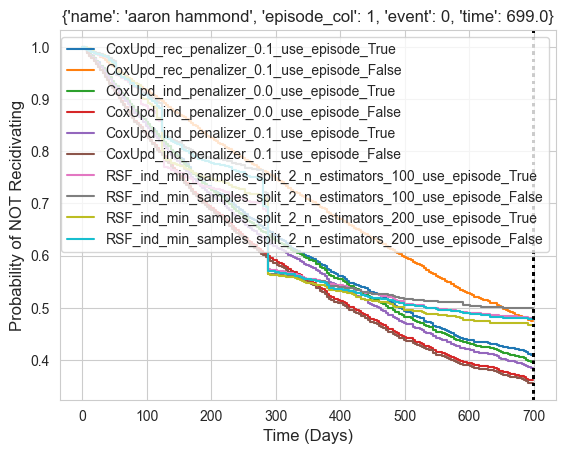

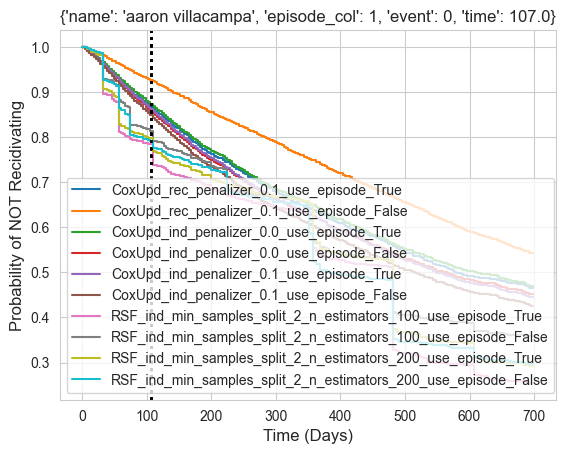

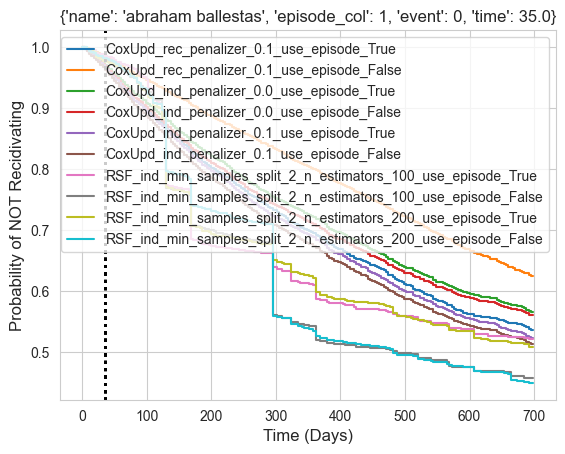

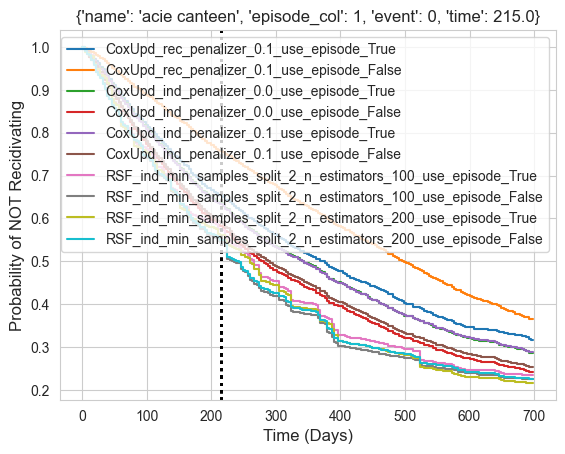

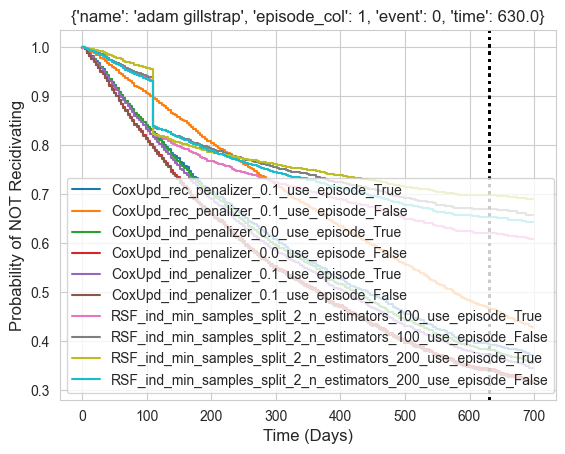

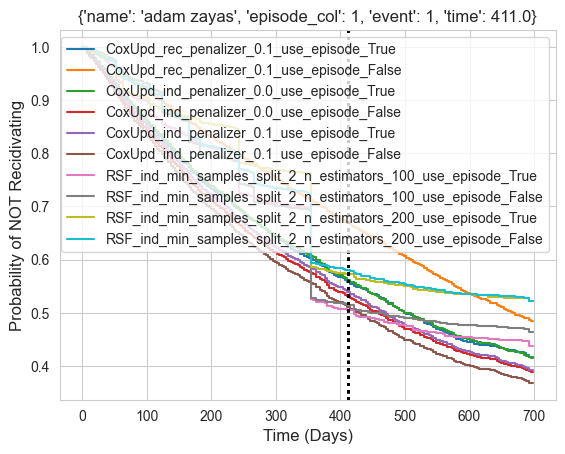

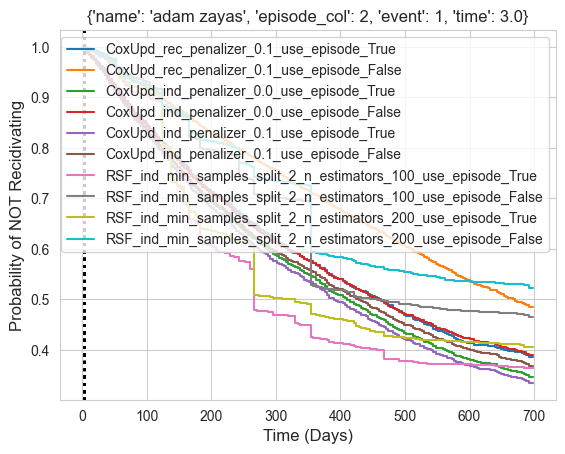

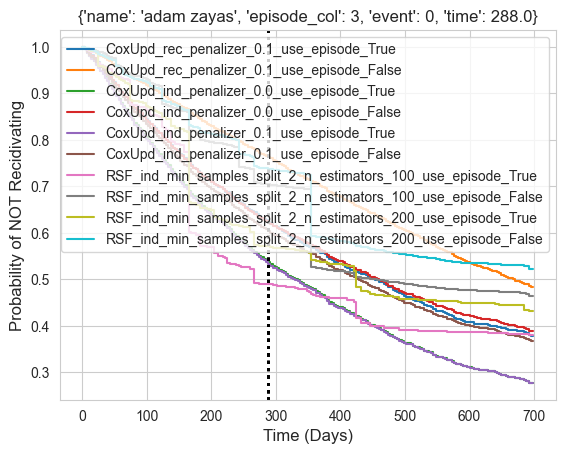

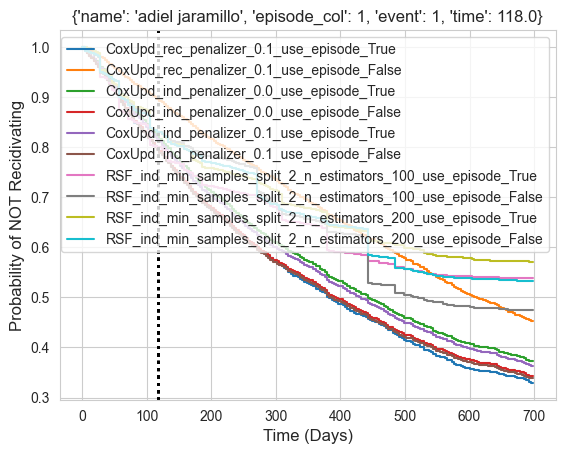

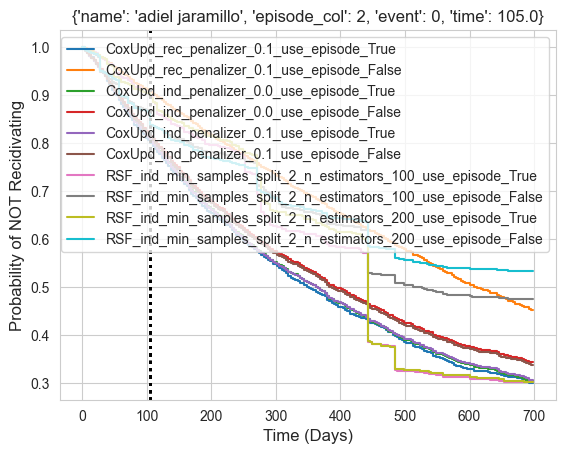

In [30]:
sns.set_style("whitegrid")

for index_test in range(10):
    for name, model in models.items():
        pred = model.predict_survival(test_model_df[features], times)
        plt.step(times, pred.iloc[index_test].values, label=name)
        sample_info = test_model_df.iloc[index_test]
        event_status = "Recidivated" if sample_info["event"] == 1 else "No Recidivism"
        time_to_event = sample_info["time"]
        plt.axvline(
            x=time_to_event,
            color="black",
            linestyle=":",
            linewidth=2,
        )
    # pred = rsf_model.predict_survival(test_model_df[rsf_model.features], times)
    # plt.step(times, pred.iloc[index_test].values, label="RSF_no_episode_col", color="red", linewidth=2)
    # sample_info = test_model_df.iloc[index_test]
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Probability of NOT Recidivating", fontsize=12)
    plt.legend()
    plt.title(f"{test_model_df.iloc[index_test][['name', 'episode_col', 'event', 'time']].to_dict()}")
    plt.show()

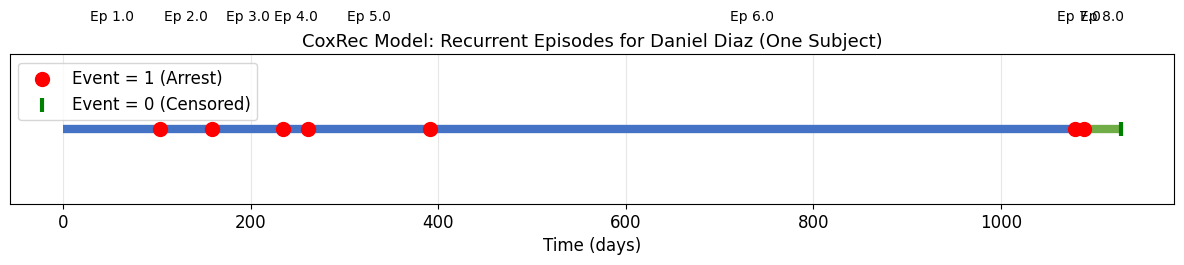

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------
# YOUR DATA (Daniel Diaz)
# ---------------------------
data = {
    "episode": [1, 2, 3, 4, 5, 6, 7, 8],
    "start": [0.0, 104.0, 159.0, 235.0, 261.0, 391.0, 1079.0, 1088.0],
    "stop": [104.0, 159.0, 235.0, 261.0, 391.0, 1079.0, 1088.0, 1128.0],
    "event": [1, 1, 1, 1, 1, 1, 1, 0]
}
df = pd.DataFrame(data)

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(12, 3))
plt.rcParams.update({'font.size': 12})

# Draw horizontal lines for each episode
for idx, row in df.iterrows():
    y = 1  # All on same line (one person)
    plt.hlines(
        y=y, 
        xmin=row["start"], 
        xmax=row["stop"], 
        linewidth=6, 
        color="#4472C4" if row["event"] == 1 else "#70AD47"
    )
    # Episode number
    plt.text(
        (row["start"] + row["stop"])/2, 
        y+0.08, 
        f"Ep {row['episode']}", 
        ha="center", fontsize=10
    )

# Mark events (1 = arrest)
events = df[df["event"] == 1]
plt.scatter(events["stop"], np.ones(len(events)), color="red", s=100, zorder=5, label="Event = 1 (Arrest)")

# Mark censoring (0)
cens = df[df["event"] == 0]
plt.scatter(cens["stop"], np.ones(len(cens)), color="green", s=100, marker="|", linewidth=3, zorder=5, label="Event = 0 (Censored)")

# Labels and style
plt.yticks([])
plt.xlabel("Time (days)", fontsize=12)
plt.title("CoxRec Model: Recurrent Episodes for Daniel Diaz (One Subject)", fontsize=13)
plt.legend(loc="upper left")
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

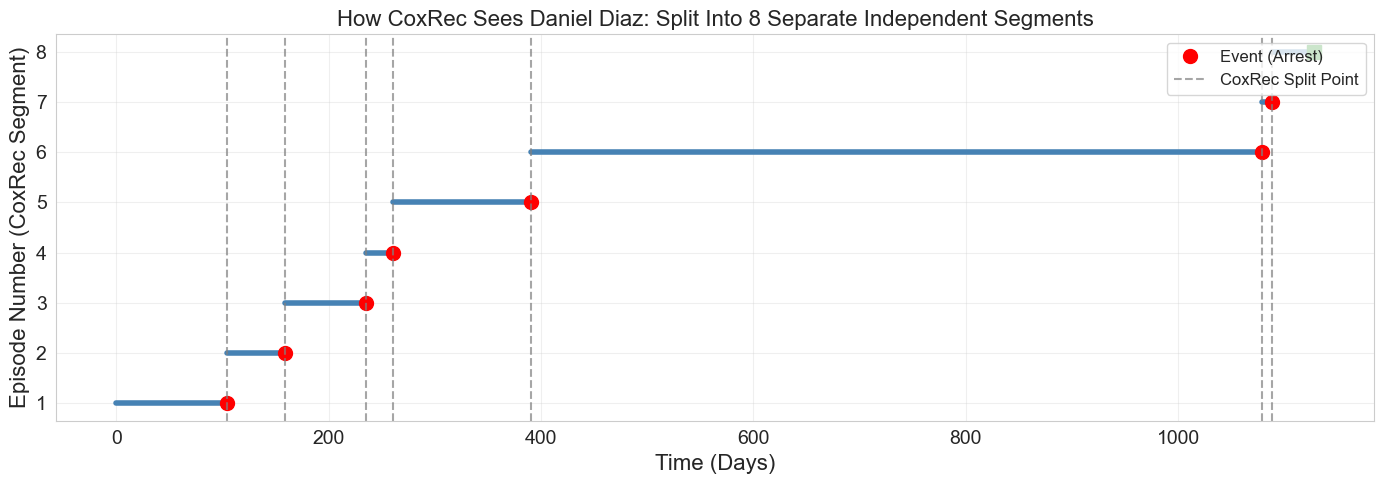

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# YOUR EXACT DATA FOR DANIEL DIAZ
episodes = [1, 2, 3, 4, 5, 6, 7, 8]
starts =   [0.0, 104.0, 159.0, 235.0, 261.0, 391.0, 1079.0, 1088.0]
stops =    [104.0, 159.0, 235.0, 261.0, 391.0, 1079.0, 1088.0, 1128.0]
events =   [1, 1, 1, 1, 1, 1, 1, 0]

# PLOT
plt.figure(figsize=(14, 5))

# Draw EACH EPISODE AS A SEPARATE LINE SEGMENT
for i in range(len(episodes)):
    ep = episodes[i]
    s = starts[i]
    e = stops[i]
    ev = events[i]
    
    # Draw line for this episode (CoxRec sees this as ONE segment)
    plt.plot([s, e], [ep, ep], linewidth=4, color="steelblue")
    
    # Mark end of episode
    if ev == 1:
        plt.plot(e, ep, "ro", markersize=10, label="Event (Arrest)" if i==0 else "")
    else:
        plt.plot(e, ep, "gs", markersize=10, label="Censored" if i==0 else "")

# Add VERTICAL LINES showing WHERE COXREC SPLITS THE DATA
split_points = [104, 159, 235, 261, 391, 1079, 1088]
for t in split_points:
    plt.axvline(x=t, color="gray", linestyle="--", alpha=0.7, 
                label="CoxRec Split Point" if t == split_points[0] else "")

# --------------------------
# BIGGER FONTS FOR AXES LABELS
# --------------------------
plt.xlabel("Time (Days)", fontsize=16)  # MADE X AXIS BIGGER
plt.ylabel("Episode Number (CoxRec Segment)", fontsize=16)  # MADE Y AXIS BIGGER
plt.title("How CoxRec Sees Daniel Diaz: Split Into 8 Separate Independent Segments", fontsize=16)

# --------------------------
# ALSO MAKE TICK NUMBERS BIGGER
# --------------------------
plt.xticks(fontsize=14)
plt.yticks(episodes, fontsize=14)

plt.legend(loc="upper right", fontsize=12)  # legend also bigger
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------
# STEP 1: Calculate HOW MANY EPISODES EACH SUBJECT HAS
# ------------------------------------------------------
# Assuming you have a DataFrame with: id, k (episode number), train/test flag
# Replace with your real column names!

# Count total episodes per subject (group by individual)
ep_count_train = train_df.groupby('id')['k'].max().value_counts().sort_index()
ep_count_test = test_df.groupby('id')['k'].max().value_counts().sort_index()

# ------------------------------------------------------
# STEP 2: Create a combined DataFrame for plotting
# ------------------------------------------------------
plot_df = pd.DataFrame({
    'Train': ep_count_train,
    'Test': ep_count_test
}).fillna(0).astype(int)  # fill missing k with 0

# ------------------------------------------------------
# STEP 3: Plot grouped bar chart
# ------------------------------------------------------
plt.figure(figsize=(10, 5))
plot_df.plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#ff7f0e'])

plt.title('Distribution of Number of Episodes (k) per Subject\nTrain vs Test Set', fontsize=12)
plt.xlabel('Number of Episodes (k)', fontsize=11)
plt.ylabel('Number of Subjects', fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'id'